In [1]:
from profiling_and_attack import mlp_eshard, information, cnn, cnn_ASCAD, mlp

from sklearn.preprocessing import StandardScaler
from utils import *
from tensorflow.keras import Model
from tensorflow.keras.utils import to_categorical
from sklearn.decomposition import PCA
import sys
from matplotlib import pyplot as plt

2025-03-05 14:35:14.179244: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-05 14:35:14.397425: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-05 14:35:14.397463: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-05 14:35:14.437052: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-05 14:35:14.512939: I tensorflow/core/platform/cpu_feature_guar

In [2]:
import tensorflow as tf

def train_linear_probe(x_train, y_train, epochs=5):
    """
    Defines and trains a linear probe with a dense layer on top of extracted features.
    
    Args:
        x_train (np.array or tf.Tensor): Training features.
        y_train (np.array or tf.Tensor): Training labels.
        
    Returns:
        tf.keras.Model: Trained linear probe model.
    """
    # Define the linear probe model (a simple dense layer on the input features)
    num_classes = len(set(y_train))  # Infer number of classes from labels
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=x_train.shape[1:]),  # Input shape based on feature size
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    # Compile the model
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    # Train the linear probe
    model.fit(x_train, y_train, epochs=epochs, batch_size=400)

    return model
def hw(input):

    result = np.zeros_like(input)
    for i in range(8):
        result += (input >> i) & 0x1
    return result

In [3]:
dataset_id = 'ches_ctf'
traces_dim = 15000

n_prof= 30000
import gc

lm = "HW"
target_byte = 2
path = "/mnt/d/Datasets"
dataset = load_dataset(dataset_id, path, target_byte, traces_dim, leakage_model=lm, n_prof=n_prof)
pi_og, pi_patch_new, pi_patch_og = [], [], []
dataset.x_profiling, dataset.x_attack = scale_dataset(dataset.x_profiling, dataset.x_attack, StandardScaler())


## Training model and plotting PI evolution

In [6]:
import gc

n_epochs = 200
batch_size=400
model = mlp_eshard(9,traces_dim)
training = False
pi_prof, pi_attack = [], []
model_name = f"ches_ctf_byte_{target_byte}"
if not training:
        #Exit if we do now want to train
        raise KeyboardInterrupt
for i in range(n_epochs):
        model.fit(
        x=dataset.x_profiling,
        y=to_categorical(dataset.profiling_labels, num_classes=dataset.classes),
        batch_size=batch_size,
        verbose=2,
        epochs=1,
        shuffle=True)
        model.save_weights(f"model_checkpoints/{model_name}_{(i+1):02d}.weights.h5")
        pi_attack.append(information(model.predict(dataset.x_attack), dataset.attack_labels, dataset.classes))
        pi_prof.append(information(model.predict(dataset.x_profiling[:10000]), dataset.profiling_labels[:10000], dataset.classes))
        print(i, pi_prof[-1], pi_attack[-1])
        gc.collect()

2025-03-05 14:41:22.932641: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-03-05 14:41:23.053232: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-03-05 14:41:23.053276: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-03-05 14:41:23.054844: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-03-05 14:41:23.054877: I external/local_xla/xla/stream_executor

Model: "mlp_softmax"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 15000)]           0         
                                                                 
 dense (Dense)               (None, 40)                600040    
                                                                 
 dense_1 (Dense)             (None, 40)                1640      
                                                                 
 dense_2 (Dense)             (None, 40)                1640      
                                                                 
 dense_3 (Dense)             (None, 40)                1640      
                                                                 
 output (Dense)              (None, 9)                 369       
                                                                 
Total params: 605329 (2.31 MB)
Trainable params: 605329

KeyboardInterrupt: 

In [4]:
def reload_model(epoch= 10, layers=1):
    global layer, model, tmp, tmp_att
    #layer = layers
    model.load_weights(f"model_checkpoints/{model_name}_{epoch:02d}.weights.h5")
    outputs = [model.layers[layer].output for layer in range(0, len(model.layers))]
    new_model = Model(model.inputs, outputs)
    tmp =  new_model.predict(dataset.x_profiling)
    #print(tmp.shape)
    tmp_att = new_model.predict(dataset.x_attack).copy()
sbox_ins = (dataset.profiling_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.profiling_keys[:, dataset.target_byte].astype(np.uint8))
probes_for_bit = []

def only_reload(epoch):
    model.load_weights(f"model_checkpoints/{model_name}_{epoch:02d}.weights.h5")


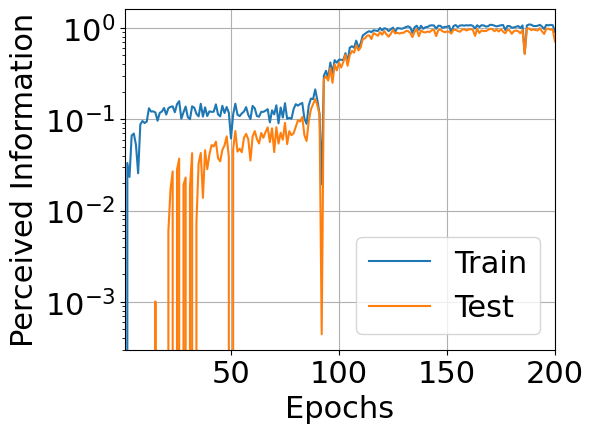

In [51]:
import gc
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
#print(len(pi_attack))
plt.plot(range(1, 201), pi_prof, label="Train")
plt.plot(range(1, 201), pi_attack, label="Test")

plt.yscale('log')
plt.xlabel("Epochs")
plt.ylabel("Perceived Information")
plt.xlim([1, 200])
plt.grid()
plt.legend()
plt.tight_layout()
#plt.savefig("PI_ches.png", dpi=200)
plt.show()


## Logit Visualization

104/104 [==============================] - 0s 2ms/step


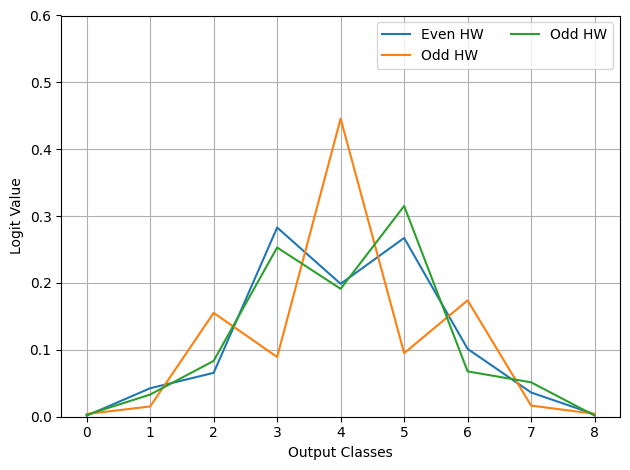

[1088 1249 1574 2156 2485 2688 2822 2830 2904 3319 3325 3648 3809 4104
 4751 4799 4844 5027 5577 5824 5941 6017 6173 6256 6407 6614 7238 7268
 8351 8433 8452 8561 8570 9001 9174 9295]
2/2 [==============================] - 0s 2ms/step
[ 131  173  186  187  203  204  238  242  327  349  393  431  555  603
  614  639  641  658  709  713  769  847  872  950 1030 1068 1069 1121
 1146 1184 1204 1244 1374 1383 1392 1460 1467 1522 1527 1608 1614 1634
 1668 1699 1758 1785 1816 1855 1859 1860 1902 1903 1906 1941 1957 1999
 2022 2043 2107 2126 2134 2152 2218 2226 2347 2371 2391 2413 2491 2493
 2510 2525 2527 2569 2593 2599 2617 2695 2696 2778 2831 2854 2880 2901
 2923 2973 3005 3009 3057 3226 3266 3308 3309 3400 3425 3457 3471 3496
 3510 3513 3528 3589 3630 3639 3686 3695 3769 3782 3785 3869 3874 3916
 3922 3953 4011 4064 4091 4102 4153 4204 4243 4254 4285 4319 4352 4368
 4400 4405 4432 4459 4474 4476 4524 4569 4573 4590 4638 4686 4758 4767
 4807 4871 4880 4906 4961 4994 5005 5011 5067 5097 5128

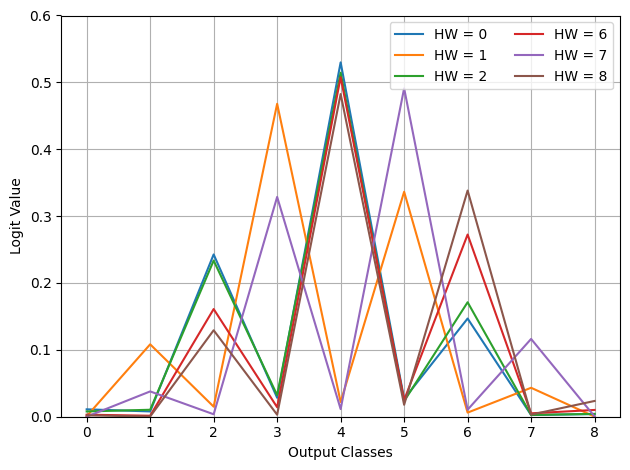

In [11]:
#reload_model(199)
out_logits = []
for i in [0, 1,2]:
    indices, = np.where(dataset.attack_labels%3 == i)
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=f"Even HW" if i == 0 else "Odd HW")
plt.ylim([0, 0.6])
plt.grid()
plt.legend(ncol=2, loc=1)
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")
plt.tight_layout()
plt.show()
gc.collect()
#reload_model(199)
out_logits = []
for i in [0,1,2, 6, 7,8]:
    indices, = np.where(dataset.attack_labels == i)
    print(indices)
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=f"HW = {i}")
plt.ylim([0, 0.6])
plt.grid()
plt.legend(ncol=2, loc=1)
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")
plt.tight_layout()
plt.show()

## PCA stuff


313/313 [==============================] - 0s 1ms/step


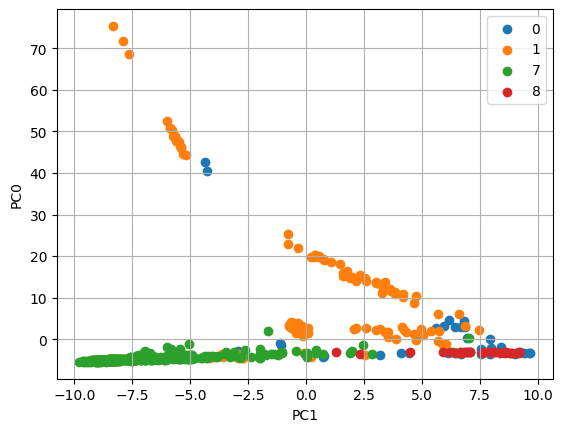

313/313 [==============================] - 0s 1ms/step


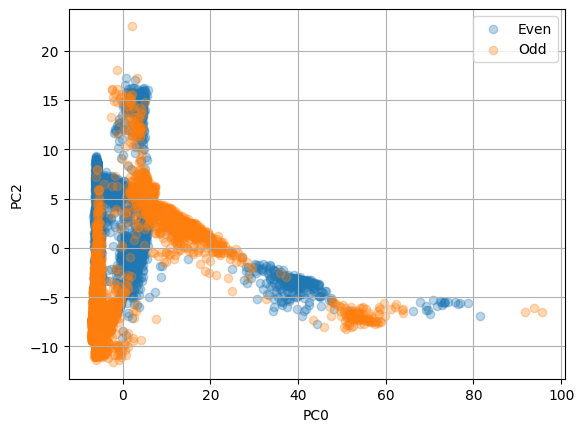

In [16]:
layer = 4
comp_n= 3
from sklearn.decomposition import PCA
gc.collect()
reload_model(199)
new_pca = PCA(n_components=comp_n)

#new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.fit_transform(tmp_att[layer])
in1 = 1
in2 = 0
for i in [0,1,7,8]:
    indices = np.where(dataset.attack_labels == i)
    plt.scatter(new_s1_att[indices,in1], new_s1_att[indices,in2], label=i)
plt.legend()
plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.grid()
plt.show()


comp_n=3
reload_model(150)
new_pca = PCA(n_components=comp_n)
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.fit_transform(tmp_att[layer])
in1 = 0
in2 = 2
for i in [0,1]:
    indices = np.where(dataset.attack_labels%2 == i)
    plt.scatter(new_s1_att[indices,in1], new_s1_att[indices,in2], label="Even" if i == 0 else "Odd", alpha=0.3)
plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
plt.legend()
plt.grid()
plt.show()

## Activation Patching